# Economic Freedom and Fintech Adoption

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

In [7]:
fintech = pd.read_csv("fintech_score_2024.csv").rename(
    columns={"countrynewwb": "Country"}
)
freedom = pd.read_csv("economic_freedom_clean.csv")

fintech["Country"] = fintech["Country"].replace({
    "Congo, Dem. Rep.": "Democratic Republic of Congo",
    "Congo, Rep.": "Republic of Congo",
    "Cote d'Ivoire": "Côte d’Ivoire",
    "Egypt, Arab Rep.": "Egypt",
    "Gambia, The": "The Gambia",
    "Iran, Islamic Rep.": "Iran",
    "Lao PDR": "Laos",
    "Turkiye": "Turkey",
    "Venezuela, RB": "Venezuela",
    "Viet Nam": "Vietnam"
})

df = fintech.merge(freedom, on="Country")

In [8]:
x = df["Overall Score"]
y = df["fintech_score"]

rho, p_spearman = spearmanr(x, y)
r, p_pearson = pearsonr(x, y)

print(f"Countries: {len(df)}")
print(f"Spearman: {rho:.3f}, p-value: {p_spearman:.3f}")
print(f"Pearson: {r:.3f}, p-value: {p_pearson:.3f}")

Countries: 75
Spearman: 0.250, p-value: 0.031
Pearson: 0.164, p-value: 0.161


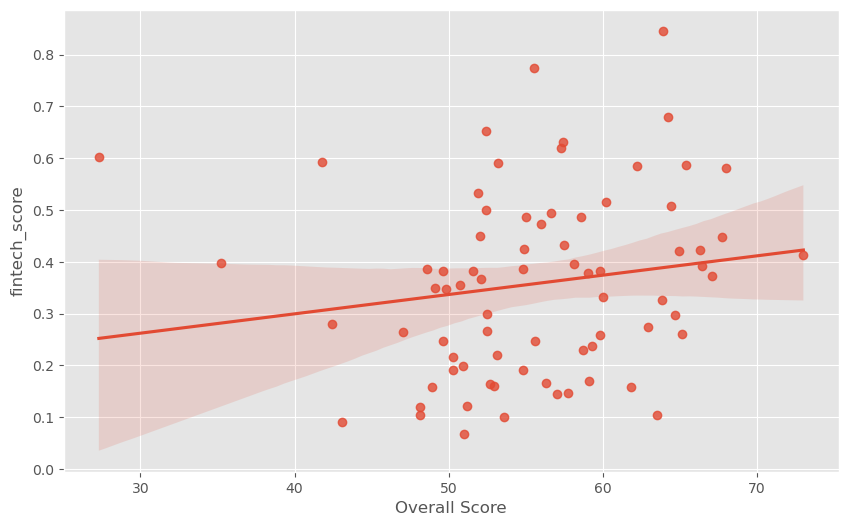

In [9]:
plt.style.use("ggplot")
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="Overall Score", y="fintech_score", seed=42)
plt.show()